**Вайцеховский Егор, 5130901/20102**

### *Упражнение 1.2.*

Скачаем с сайта бесплатных звуков https://freesound.org/ образец звука гитары и исследуем его. Для удобства используем библиотеку thinkdsp.

Откроем скачанный файл, нормализуем и выведем на экран.
Код и результат его выполнения выглядят так:

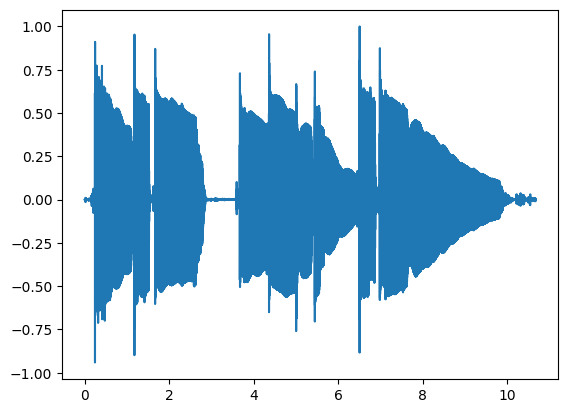

In [10]:
from thinkdsp import read_wave

wave = read_wave('guitar.wav')
wave.normalize()
wave.plot()
wave.make_audio()

Данный аудиофайл достаточно длинный, выделим из него отрезок в полсекунды, начиная с 0 секунды аудио файла.

Представленный ниже код выводит полученный сегмент на экран:

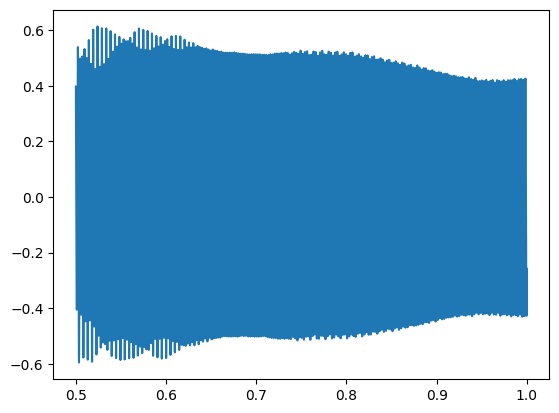

In [43]:
segment = wave.segment(start=0.5, duration=0.5)
segment.plot()
segment.make_audio()


Разложим полученный отрезок в спектр до 2000 частоты - далее частоты примерно равны нулю:
Основная частота 230 Гц

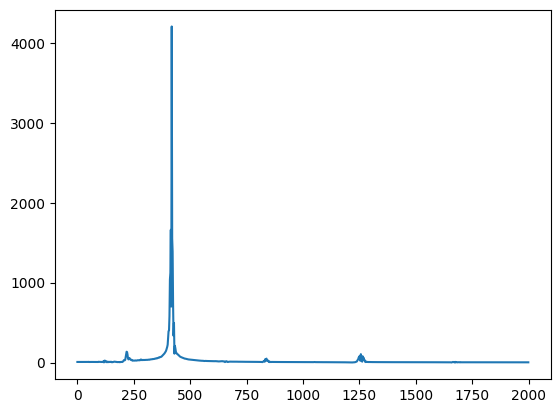

In [44]:
spectrum = segment.make_spectrum()
spectrum.plot(high=2000)
spectrum.make_wave().make_audio()

Теперь рассмотрим функции high_pass, low_pass и band_stop, которые фильтруют гармоники.

*low_pass:*

Данная функция полностью убирает частоты выше 1000. Поэтому звук становится более «глухим/отдалённым/невнятным».

Представленный ниже код сохраняет музыкальный фрагмент, затем применяет функцию low_pass, выводит его спектр на экран и опять сохраняет фрагмент.
Полученный спектр выглядит так:


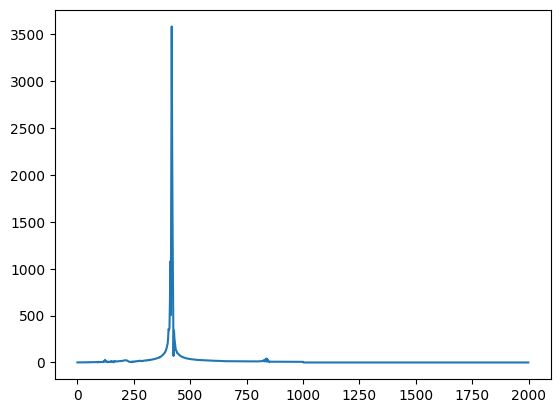

In [39]:
spectrum.low_pass(1000)
spectrum.plot(high=2000)
spectrum.make_wave().make_audio()

*high_pass:*

Применим данную функцию к исходному отрезку. Функция в свою очередь убирает частоты ниже заданной - 1000, и звук становится более резким, "писклявым" и менее глубоким.

Полученный спектр выглядит так:

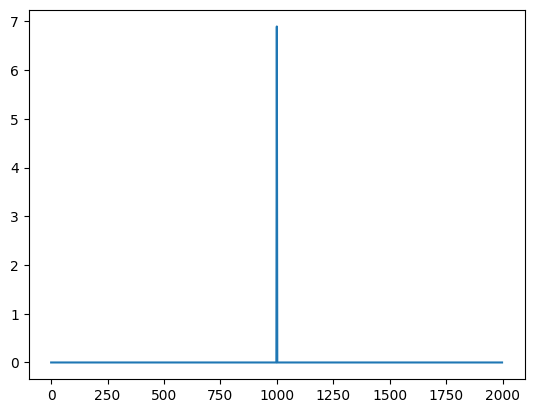

In [40]:
spectrum.high_pass(1000)
spectrum.plot(high=2000)
spectrum.make_wave().make_audio()

*band_stop:*

Применим данную функцию к исходному отрезку.

Функция убирает частоты заданного диапазона - у нас 0 - 380 и 480 - 1000, и звук лишается глубины и разнообразия.

Полученный спектр выглядит так:

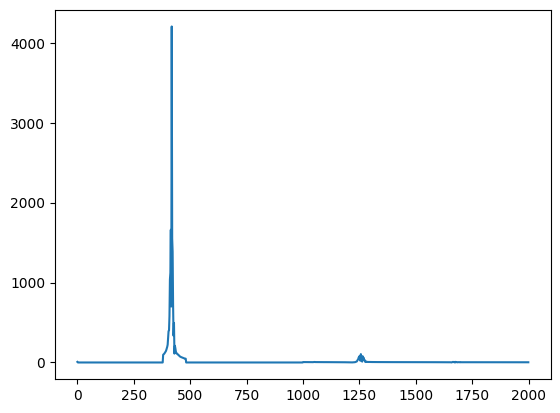

In [47]:
spectrum.band_stop(low_cutoff=0, high_cutoff=380)
spectrum.band_stop(low_cutoff=480, high_cutoff=1000)
spectrum.plot(high=2000)
spectrum.make_wave().make_audio()

### *Упражнение 1.3.*

В настоящей части работы необходимо создать сигнал, состоящий из синусов и косинусов разной частоты:

Код и результат его выполнения выглядят так:

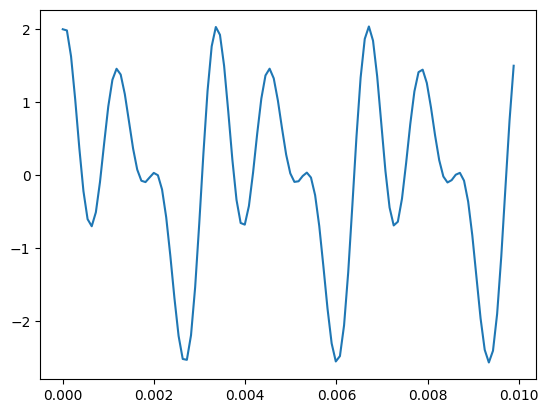

In [70]:
from thinkdsp import SinSignal
from thinkdsp import CosSignal

signal = (SinSignal(freq=300, amp=1.0) +
          CosSignal(freq=600, amp=1.0) +
          CosSignal(freq=900, amp=1.0))
signal.plot()

Создадим файл для прослушивания получившегося звука, длинной 1 секунда.

Звук напоминает гудок автомобиля:


In [62]:
wave = signal.make_wave(duration=1)
wave.apodize()
wave.make_audio()

Выведем спектр полученного сигнала:
Спектр соответствует ожиданиям - пики частот находятся именно на тех значениях, которые мы задали при создании.

Результат выглядит следующим образом:


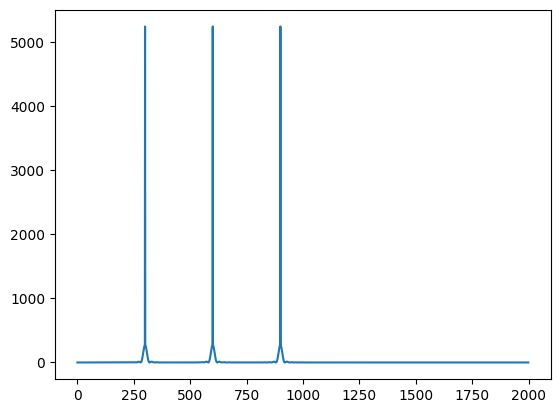

In [63]:
spectrum = wave.make_spectrum()
spectrum.plot(high=2000)

Теперь добавим в сигнал частоту, не кратную 300, например, 111
Видим, что графически сигнал значительно отличается от первоначального.

Однако звук изменился не сильно, хотя теперь в нём различаются еле заментые колебания частот.

Полученный сигнал имеет следующий вид:

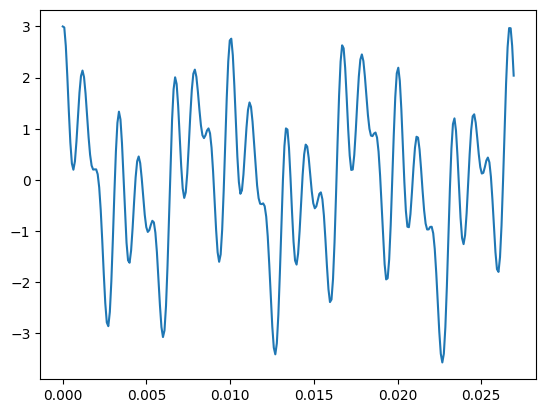

In [71]:
signal += CosSignal(freq=111, amp=1.0)
signal.plot()
signal.make_wave().make_audio()

Выведем спектр полученного сигнала. Ожидаемо, в спектре появился ещё один сигнал.

Результат выглядит следующим образом:

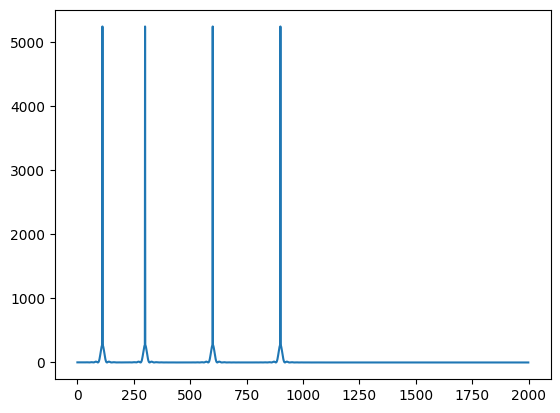

In [72]:
wave = signal.make_wave(duration=1)
wave.apodize()
spectrum = wave.make_spectrum()
spectrum.plot(high=2000)

### *Упражнение 1.4.*

Теперь напишем функцию для увеличения и уменьшения скорости воспроизведения аудиофайла.

Нам необходимо прочитать фрагмент аудио и вывести его спектр.

Код и результат его выполнения выглядят так:

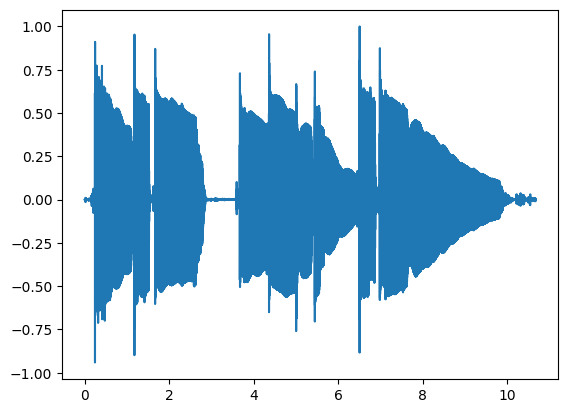

In [79]:
wave = read_wave('guitar.wav')
wave.normalize()
wave.plot()
wave.make_audio()

Функция для ускорения воспроизведения будет выглядеть следующим образом:


In [74]:
def stretch(custom_wave, factor):
    custom_wave.ts *= factor
    custom_wave.framerate /= factor

Данная функция изменяет массив моментов выборки сигнала - ts, которое используется для корректного отображения временной шкалы в plot, и framerate, что,  и ускоряет произведение.
Ускорим воспроизведение в 2 раза - framerate = 0.5

После выполнения получаем аудиофайл, который ускорен в 2 раза. Ниже представлена полученная спектрограмма:

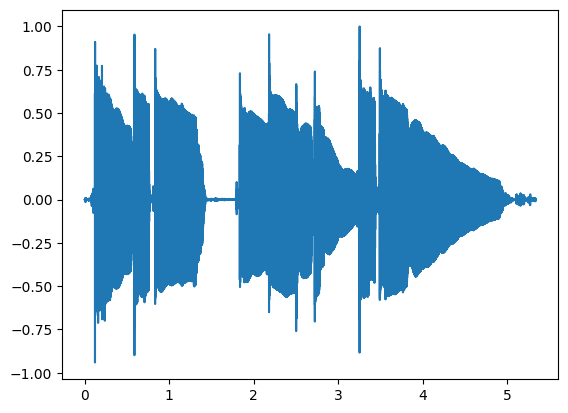

In [75]:
stretch(wave, 0.5)
wave.plot()
wave.make_audio()

Как видно из рисунка, полученная спектрограмма ничем не отличается от исходной, кроме длительности аудио фрагмента - он меньше в 2 раза.

Аналогичные действия необходимы для замедления воспроизведения записи. Замедлим запись в 1.5 раза



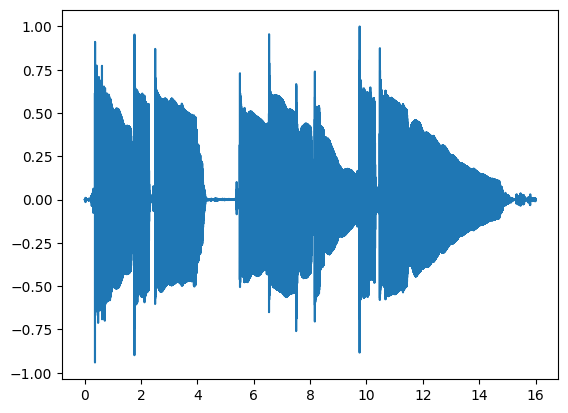

In [80]:
stretch(wave, 1.5)
wave.plot()
wave.make_audio()